C:\Users\Xdream\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Xdream\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__periodicity is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Xdream\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


平均绝对百分比误差为: 1.38%
实际值在预测上下限区间的概率为: 90.08%


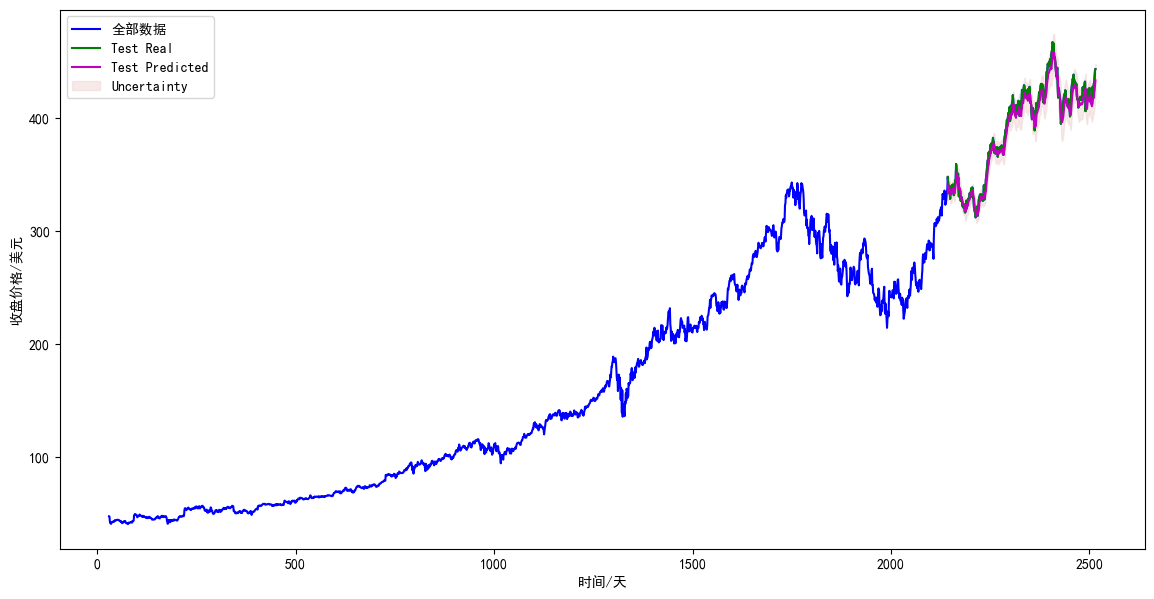

In [10]:
import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel,RBF,RationalQuadratic,ExpSineSquared
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 读取数据
data1 = pd.read_csv('MSFT_all.csv', parse_dates=['Date'], index_col='Date')
# 检查数据是否已经是按日期升序排列
if not data1.index.is_monotonic_increasing:
    # 如果不是升序排列，则进行排序
    data1 = data1.sort_index(ascending=True)
# 去除 'Close/Last' 列中的货币符号并转换为浮点数
data1['Close/Last'] = data1['Close/Last'].str.replace(r'[^\d.]', '', regex=True).astype(float)
stock1 = data1['Close/Last'].values 

# 定义滑动窗口大小
window_size = 30

# 创建滑动窗口数据集
def create_sliding_window(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# 使用滑动窗口创建训练集和测试集
X, y = create_sliding_window(stock1, window_size)
trainX, testX, trainY, testYreal = train_test_split(X, y, test_size=0.15, shuffle=False)

# 标准化数据
scaler = StandardScaler()
trainY_scaled = scaler.fit_transform(trainY.reshape(-1, 1)).ravel()

# GPR模型: Rational Quadratic * Periodic + WhiteKernel
kernel = ConstantKernel() * RationalQuadratic(length_scale=1.0, alpha=1.0) * ExpSineSquared(length_scale=1.0, periodicity=30) + WhiteKernel(noise_level=1)
# GPR模型:Matern 和 WhiteKernel 组合
#kernel = ConstantKernel() * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1)

gprMdl = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1, normalize_y=True)
gprMdl.fit(trainX, trainY_scaled)

# 滚动预测
testYpd_scaled, sigma = [], []
for i in range(len(testX)):
    # 预测
    pd_scaled, std = gprMdl.predict([testX[i]], return_std=True)
    testYpd_scaled.append(pd_scaled[0])
    sigma.append(std[0])

# 反标准化预测值
testYpd = scaler.inverse_transform(np.array(testYpd_scaled).reshape(-1, 1)).ravel()
Lower = scaler.inverse_transform((np.array(testYpd_scaled) - 1.96 * np.array(sigma)).reshape(-1, 1)).ravel()
Upper = scaler.inverse_transform((np.array(testYpd_scaled) + 1.96 * np.array(sigma)).reshape(-1, 1)).ravel()

# 计算误差
erravg = np.mean(np.abs(testYpd - testYreal) / testYreal)
print(f'平均绝对百分比误差为: {erravg:.2%}')

# 计算测试集实际值在上下限的概率
y3 = (testYreal > Lower) & (testYreal < Upper)
errarea = np.mean(y3)
print(f'实际值在预测上下限区间的概率为: {errarea:.2%}')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号 '-' 显示为方块的问题

# 作图
plt.figure(figsize=(14, 7))
plt.plot(range(window_size, len(stock1)), stock1[window_size:], 'b', label='全部数据')
plt.plot(range(len(trainX) + window_size, len(stock1)), testYreal, 'g', label='Test Real')
plt.plot(range(len(trainX) + window_size, len(stock1)), testYpd, 'm', label='Test Predicted')
plt.fill_between(range(len(trainX) + window_size, len(stock1)), Lower, Upper, color=[0.93333, 0.83529, 0.82353], alpha=0.5, label='Uncertainty')
plt.xlabel('时间/天')
plt.ylabel('收盘价格/美元')
plt.legend()
plt.show()

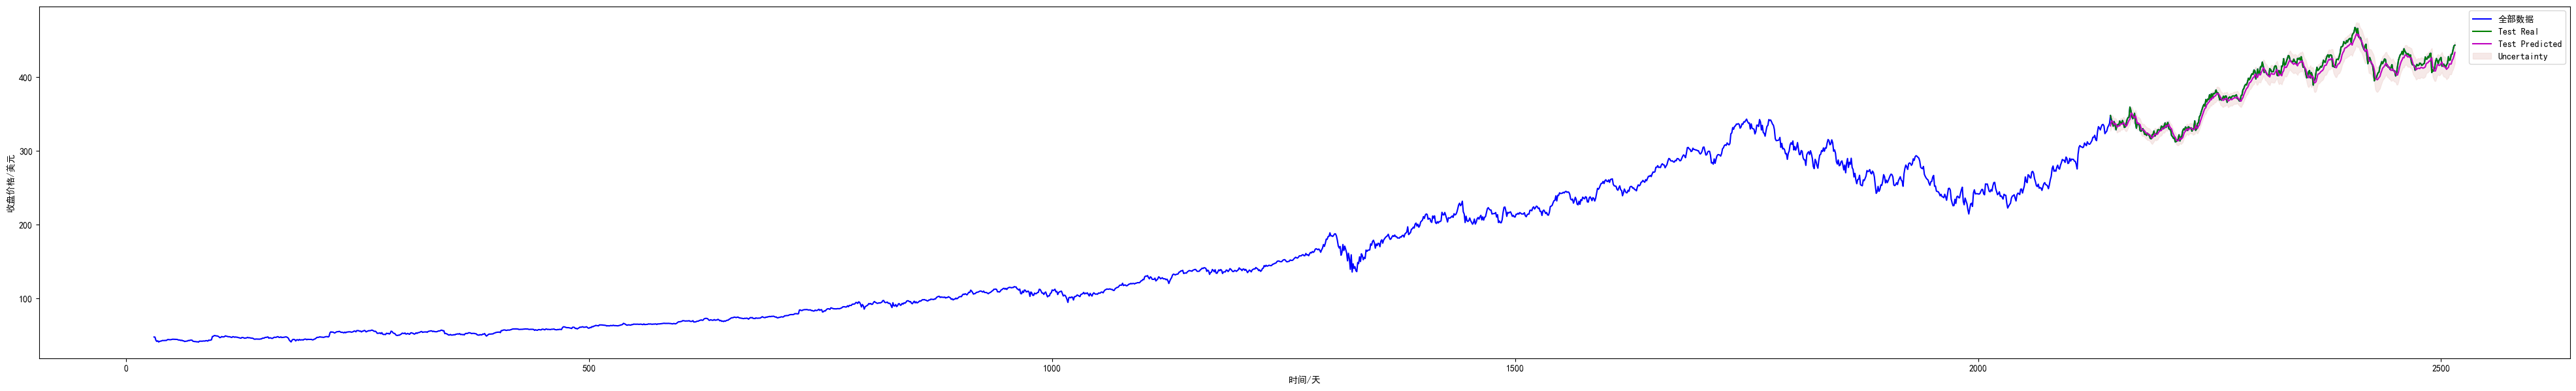

In [11]:
# 作图
plt.figure(figsize=(50, 7))
plt.plot(range(window_size, len(stock1)), stock1[window_size:], 'b', label='全部数据')
plt.plot(range(len(trainX) + window_size, len(stock1)), testYreal, 'g', label='Test Real')
plt.plot(range(len(trainX) + window_size, len(stock1)), testYpd, 'm', label='Test Predicted')
plt.fill_between(range(len(trainX) + window_size, len(stock1)), Lower, Upper, color=[0.93333, 0.83529, 0.82353], alpha=0.5, label='Uncertainty')
plt.xlabel('时间/天')
plt.ylabel('收盘价格/美元')
plt.legend()
plt.show()

In [12]:
trainX

array([[ 47.59,  46.9 ,  47.17, ...,  46.39,  45.92,  47.13],
       [ 46.9 ,  47.17,  46.95, ...,  45.92,  47.13,  47.18],
       [ 47.17,  46.95,  46.67, ...,  47.13,  47.18,  47.01],
       ...,
       [307.26, 305.56, 305.41, ..., 323.38, 325.26, 326.79],
       [305.56, 305.41, 304.4 , ..., 325.26, 326.79, 331.85],
       [305.41, 304.4 , 305.41, ..., 326.79, 331.85, 334.29]])

In [13]:
testX

array([[304.4 , 305.41, 310.65, ..., 331.85, 334.29, 337.34],
       [305.41, 310.65, 308.65, ..., 334.29, 337.34, 348.1 ],
       [310.65, 308.65, 307.  , ..., 337.34, 348.1 , 342.33],
       ...,
       [427.51, 424.6 , 424.73, ..., 423.46, 430.98, 431.2 ],
       [424.6 , 424.73, 428.15, ..., 430.98, 431.2 , 437.42],
       [424.73, 428.15, 426.59, ..., 431.2 , 437.42, 442.62]])